# **1. 시퀀스 데이터**
시퀀스 데이터(Sequence Data)는 시간적 혹은 순서적 관계가 중요한 데이터를 말합니다. 일반적인 데이터가 순서와 무관하게 독립적으로 다뤄지는 것과 달리, 시퀀스 데이터는 각 요소가 특정 순서에 따라 나열되어 있고 앞뒤 맥락이 의미를 가집니다. 대표적인 예로는 자연어 문장(단어의 순서 중요), 시계열 데이터(주가, 날씨 변화), 음성 신호(시간에 따른 파형), 영상 프레임(연속된 이미지) 등이 있습니다. 따라서 시퀀스 데이터는 단순한 값들의 모음이 아니라, 순서와 맥락이 포함된 정보 구조로 이해하는 것이 핵심입니다.

# **2. RNN**
RNN(Recurrent Neural Network, 순환 신경망)은 시계열 데이터나 연속적인 데이터를 다룰 때 사용되는 인공 신경망으로, 일반적인 신경망(CNN, MLP 등)이 입력을 한 번 처리하고 끝나는 것과 달리, 과거의 정보를 기억하며 다음 계산에 반영하는 특징이 있습니다. 일반적인 신경망은 현재 입력만 보고 예측하지만, 시계열 데이터나 자연어처럼 이전 정보가 중요한 경우에는 적절하지 않기 때문에 RNN이 필요합니다. RNN은 기존 신경망과 달리 자신의 출력을 다시 입력으로 사용하여 과거 정보를 기억하는 구조를 가지며, 이를 통해 시계열 데이터의 패턴을 학습할 수 있습니다.  그러나 일반적인 RNN은 장기 의존성(Long-Term Dependency) 문제로 인해 학습이 어려울 수 있으며, 이를 해결하기 위해 장단기 메모리(Long Short-Term Memory, LSTM)나 게이트 순환 유닛(Gated Recurrent Unit, GRU)과 같은 변형 모델이 개발되었습니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FdVaNhP%2FbtsL7gh0fgx%2FAAAAAAAAAAAAAAAAAAAAAAwNLiDocUQPAciWVZGXyIIGxbsuL1Hqs8bQ5W7BA2_4%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3D8N5fTlGr4eOWZVKRWOTxgAawfvM%253D'>

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fbmt1u0%2FbtsP7bXvObp%2FAAAAAAAAAAAAAAAAAAAAAItFvW9XMJosd1e6Q2sgH1zDaTOfz7l8YZsfevc10kNw%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3DY05mTYU%252FSi1bM60%252Fq1Jr%252FWg6suM%253D'>

> 은닉층에 있는 RNN의 처리 단위를 셀(cell)이라고 부르며, 셀의 출력을 은닉 상태(hidden state)라고 합니다. RNN은 시점(time step)에 따라서 입력을 받는데 현재 시점의 hidden state인 h𝑡연산을 위해 직전 시점의 hidden state인 h𝑡−1를 입력받습니다. 이것이 RNN이 과거의 정보를 기억할 수 있는 방법입니다.

h(셀): 가중치들의 모음.
이전 기억들을 다음 히든 레이어에 보낸다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FHGHef%2FbtsL5Qkxoi5%2FAAAAAAAAAAAAAAAAAAAAAD9pmNCzz3qG1qF24-bPaTE6IY3PHjp2BHrfjzLBJTkk%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1756652399%26allow_ip%3D%26allow_referer%3D%26signature%3D96oEBd21t819ImE%252F%252BkT7jOzWIKo%253D'>

> 하이퍼볼릭탄젠트 함수는 시그모이드 함수와 달리 -1 ~ 1의 범위 값으로 값을 반환하는 함수입니다. 반환값의 범위가 시그모이드 함수보다 크므로 일반적으로 은닉층에서는 시그모이드 함수보다 더 잘 동작합니다.

# **3. RNN 모델로 이미지 분류하기**

In [ ]:
# pip install --upgrade sympy


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dset

train_dataset = dset.MNIST(root='.',
                           train=True,
                           transform=transforms.ToTensor(),
                           download=True)

test_dataset = dset.MNIST(root='.',
                          train=False,
                          transform=transforms.ToTensor())

In [ ]:
batch_size = 100

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(RNNModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True)  # batch_first=True: (배치, 길이, 특성)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
        print("self.layer_dim: ", self.layer_dim)
        print("x.size(0): ", x.size(0))
        print("self.hidden_dim: ", self.hidden_dim)
        out, hn = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        # RNN은 매 시점 이전까지의 정보를 누적하여 마지막 시점에서 전체 시퀀스 요약
        # 최종 요약 벡터 하나면 모든 정보로 충분
        # 데이터가 누적되기 때문에 마지막 데이터만 가져옴.
        return out


        # out: 모든 시점의 은닉 출력(배치, 길이, hidden_dim)
        # hn: 각 층의 마지막 시점 은닉 상태(num_layers, 배치, hidden_dim)

```
(batch, seq_len, input_size) ← if batch_first=True
(seq_len, batch, input_size) ← if batch_first=False (기본값)
```

In [ ]:
input_dim = 28
hidden_dim = 100
layer_dim = 1
output_dim = 10
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = RNNModel(input_dim, hidden_dim, layer_dim, output_dim).to(device)
model

RNNModel(
  (rnn): RNN(28, 100, batch_first=True)
  (fc): Linear(in_features=100, out_features=10, bias=True)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
num_epochs = 20


for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        images = images.view(-1, input_dim, input_dim)  # -1에 나머지 크기가 들어감..?

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    model.eval()
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        images = images.view(-1, 28, input_dim)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum()

        accuracy = 100 * correct / total

    print('Epoch: {}. Loss: {}. Accuracy: {}'.format(epoch, loss.item(), accuracy))

Epoch: 0. Loss: 2.1305651664733887. Accuracy: 28.760000228881836
Epoch: 1. Loss: 1.2428233623504639. Accuracy: 57.36000061035156
Epoch: 2. Loss: 0.7852202653884888. Accuracy: 73.41999816894531
Epoch: 3. Loss: 0.7027381062507629. Accuracy: 77.75
Epoch: 4. Loss: 0.7708549499511719. Accuracy: 79.16000366210938
Epoch: 5. Loss: 0.40484941005706787. Accuracy: 85.98999786376953
Epoch: 6. Loss: 0.6076802611351013. Accuracy: 88.98999786376953
Epoch: 7. Loss: 0.40667489171028137. Accuracy: 90.98999786376953
Epoch: 8. Loss: 0.5731585025787354. Accuracy: 84.26000213623047
Epoch: 9. Loss: 0.2494264394044876. Accuracy: 92.73999786376953
Epoch: 10. Loss: 0.20920638740062714. Accuracy: 93.16999816894531
Epoch: 11. Loss: 0.2927287220954895. Accuracy: 93.26000213623047
Epoch: 12. Loss: 0.19131946563720703. Accuracy: 92.72000122070312
Epoch: 13. Loss: 0.18422025442123413. Accuracy: 94.38999938964844
Epoch: 14. Loss: 0.12010073661804199. Accuracy: 94.36000061035156
Epoch: 15. Loss: 0.08419869095087051. Ac

# **4. RNN을 이용한 KOSPI 예측**

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
seed = 2025
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI/13. 생성형AI/data/kospi.csv')
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce') # errors='coerce': 변환이 불가할 경우 결측치로 변환
    df = df.sort_values('Date').reset_index(drop=True)

# 결측치가 있다면 앞의 값으로 채우기
# ex) 2000-01-02, 2000-01-06, NaN, NaN, 2000-01-08
df = df.ffill().bfill()

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2000-01-02,955.440002,959.309998,923.520020,928.750000,928.750000,30614300.0
1,2000-01-06,730.549988,746.700012,722.239990,738.489990,738.489990,31433500.0
2,2000-01-08,710.049988,727.530029,700.830017,727.099976,727.099976,29793900.0
3,2000-01-09,690.929993,698.280029,685.320007,692.190002,692.190002,20236900.0
4,2000-01-11,524.690002,550.059998,522.780029,548.760010,548.760010,36644300.0


In [ ]:
FEATS = ['Open', 'High', 'Low', 'Close']

split_ratio = 0.5
split_idx = int(len(df) * split_ratio)

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = train_df[FEATS].values
X_test  = test_df[FEATS].values
y_train = train_df[['Close']].values   # (N,1) 모양
y_test  = test_df[['Close']].values

X_train = scaler_x.fit_transform(X_train)
X_test  = scaler_x.transform(X_test)

y_train = scaler_y.fit_transform(y_train)
y_test  = scaler_y.transform(y_test)

In [ ]:
X_train

array([[0.23348791, 0.2330902 , 0.22130596, 0.22017413],
       [0.12607878, 0.13132982, 0.12446595, 0.12910621],
       [0.11628783, 0.1221546 , 0.11416516, 0.12365438],
       ...,
       [0.05331531, 0.05068157, 0.04666392, 0.04684546],
       [0.04415959, 0.04835546, 0.04455661, 0.04798944],
       [0.05438515, 0.06068481, 0.05560312, 0.06155436]])

In [ ]:
X_test

array([[0.06240416, 0.0631306 , 0.06236286, 0.06250687],
       [0.07892462, 0.07729788, 0.07202859, 0.06955261],
       [0.06880412, 0.06916605, 0.06856933, 0.06759012],
       ...,
       [0.98439649, 0.98585673, 0.98588869, 0.97982017],
       [0.98057563, 0.98214739, 0.98608121, 0.98195013],
       [0.97925265, 0.97869653, 0.97422151, 0.97326269]])

In [ ]:
y_train

array([[0.22017413],
       [0.12910621],
       [0.12365438],
       ...,
       [0.04684546],
       [0.04798944],
       [0.06155436]])

In [ ]:
y_test

array([[0.06250687],
       [0.06955261],
       [0.06759012],
       ...,
       [0.97982017],
       [0.98195013],
       [0.97326269]])

In [ ]:
def make_seq(X, y, L: int):  # L: 시퀀스 길이
    Xs, ys = [], []
    for i in range(len(X) - L):
        Xs.append(X[i:i+L])     # (L, feat)
        ys.append(y[i+L])       # 다음 시점 y
    Xs = torch.tensor(np.array(Xs), dtype=torch.float32)
    ys = torch.tensor(np.array(ys), dtype=torch.float32).view(-1, 1)
    return Xs, ys

In [ ]:
sequence_length = 5
X_train_seq, y_train_seq = make_seq(X_train, y_train, sequence_length)
X_test_seq,  y_test_seq  = make_seq(X_test,  y_test,  sequence_length)

In [ ]:
# 확인
print(len(X_train)-5)
print(X_train[0: 0+5])

2251
[[0.23348791 0.2330902  0.22130596 0.22017413]
 [0.12607878 0.13132982 0.12446595 0.12910621]
 [0.11628783 0.1221546  0.11416516 0.12365438]
 [0.10715598 0.10815483 0.10670297 0.10694473]
 [0.02775854 0.03721307 0.02850161 0.03829199]]


In [ ]:
print("Train seq:", X_train_seq.shape, y_train_seq.shape)  # 2251개의 ~, 5개씩 4개의 열
print("Test  seq:", X_test_seq.shape,  y_test_seq.shape)

Train seq: torch.Size([2251, 5, 4]) torch.Size([2251, 1])
Test  seq: torch.Size([2252, 5, 4]) torch.Size([2252, 1])


In [ ]:
batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_seq, y_train_seq),
                          batch_size=batch_size, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_seq, y_test_seq),
                          batch_size=batch_size, shuffle=False, drop_last=False)

In [ ]:
class RNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True)  # tanh 기본
        self.fc = nn.Linear(hidden_size, 1)    # << Sigmoid 제거(회귀)

    def forward(self, x):
        B = x.size(0)
        h0 = torch.zeros(self.rnn.num_layers, B, self.rnn.hidden_size, device=x.device)
        out, _ = self.rnn(x, h0)               # out: [B, L, H]
        last = out[:, -1, :]                   # 마지막 시점 은닉만 사용
        yhat = self.fc(last)                   # 선형 출력
        return yhat

In [ ]:
input_size  = X_train_seq.size(2)             # 4
hidden_size = 32
num_layers  = 2
model = RNNRegressor(input_size, hidden_size, num_layers).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model

RNNRegressor(
  (rnn): RNN(4, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
epochs = 200
clip_norm = 1.0

for epoch in range(1, epochs+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)   # [B, L, 4]
        yb = yb.to(device)   # [B, 1]

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        # max_norm=clip_norm: ReLU RNN을 쓸 경우 특히 유용하지만 tanh에도 안전장치로 둡니다. (기울기 폭발 방지용)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
        optimizer.step()

        running += loss.item()

    if epoch % 20 == 0 or epoch == 1:
        print(f"[{epoch:03d}/{epochs}] train MSE: {running/len(train_loader):.6f}")

[001/200] train MSE: 0.009981
[020/200] train MSE: 0.003416
[040/200] train MSE: 0.003378
[060/200] train MSE: 0.003421
[080/200] train MSE: 0.003353
[100/200] train MSE: 0.003355
[120/200] train MSE: 0.003294
[140/200] train MSE: 0.003280
[160/200] train MSE: 0.003196
[180/200] train MSE: 0.003124
[200/200] train MSE: 0.003157


In [ ]:
model.eval()
pred_list, true_list = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = model(xb)                # 스케일된 예측
        pred_list.append(pred.cpu().numpy())
        true_list.append(yb.cpu().numpy())

pred_scaled = np.vstack(pred_list)      # (N_test, 1)
true_scaled = np.vstack(true_list)

# 원 스케일로 되돌리기(inverse transform)
pred_unscaled = scaler_y.inverse_transform(pred_scaled)
true_unscaled = scaler_y.inverse_transform(true_scaled)

from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = mean_squared_error(true_unscaled, pred_unscaled)
mae  = mean_absolute_error(true_unscaled, pred_unscaled)
print(f"Test RMSE: {rmse:.4f} | MAE: {mae:.4f}")

print("예측(앞 5개):", np.round(pred_unscaled[:5, 0], 2))
print("실제(앞 5개):", np.round(true_unscaled[:5, 0], 2))

Test RMSE: 3695.4075 | MAE: 47.0787
예측(앞 5개): [649.25 645.92 641.59 643.21 642.75]
실제(앞 5개): [596.36 602.08 600.57 595.38 611.51]


In [ ]:
pred_scaled

array([[0.08639053],
       [0.08479679],
       [0.08272678],
       ...,
       [0.87566626],
       [0.8805257 ],
       [0.8837999 ]], dtype=float32)

In [ ]:
true_scaled

array([[0.06107571],
       [0.0638136 ],
       [0.06309083],
       ...,
       [0.9798202 ],
       [0.9819501 ],
       [0.97326267]], dtype=float32)

In [ ]:
pred_unscaled

array([[ 649.248  ],
       [ 645.91833],
       [ 641.5936 ],
       ...,
       [2298.2107 ],
       [2308.363  ],
       [2315.2036 ]], dtype=float32)

In [ ]:
true_unscaled

array([[ 596.36  ],
       [ 602.08  ],
       [ 600.57  ],
       ...,
       [2515.81  ],
       [2520.2598],
       [2502.11  ]], dtype=float32)

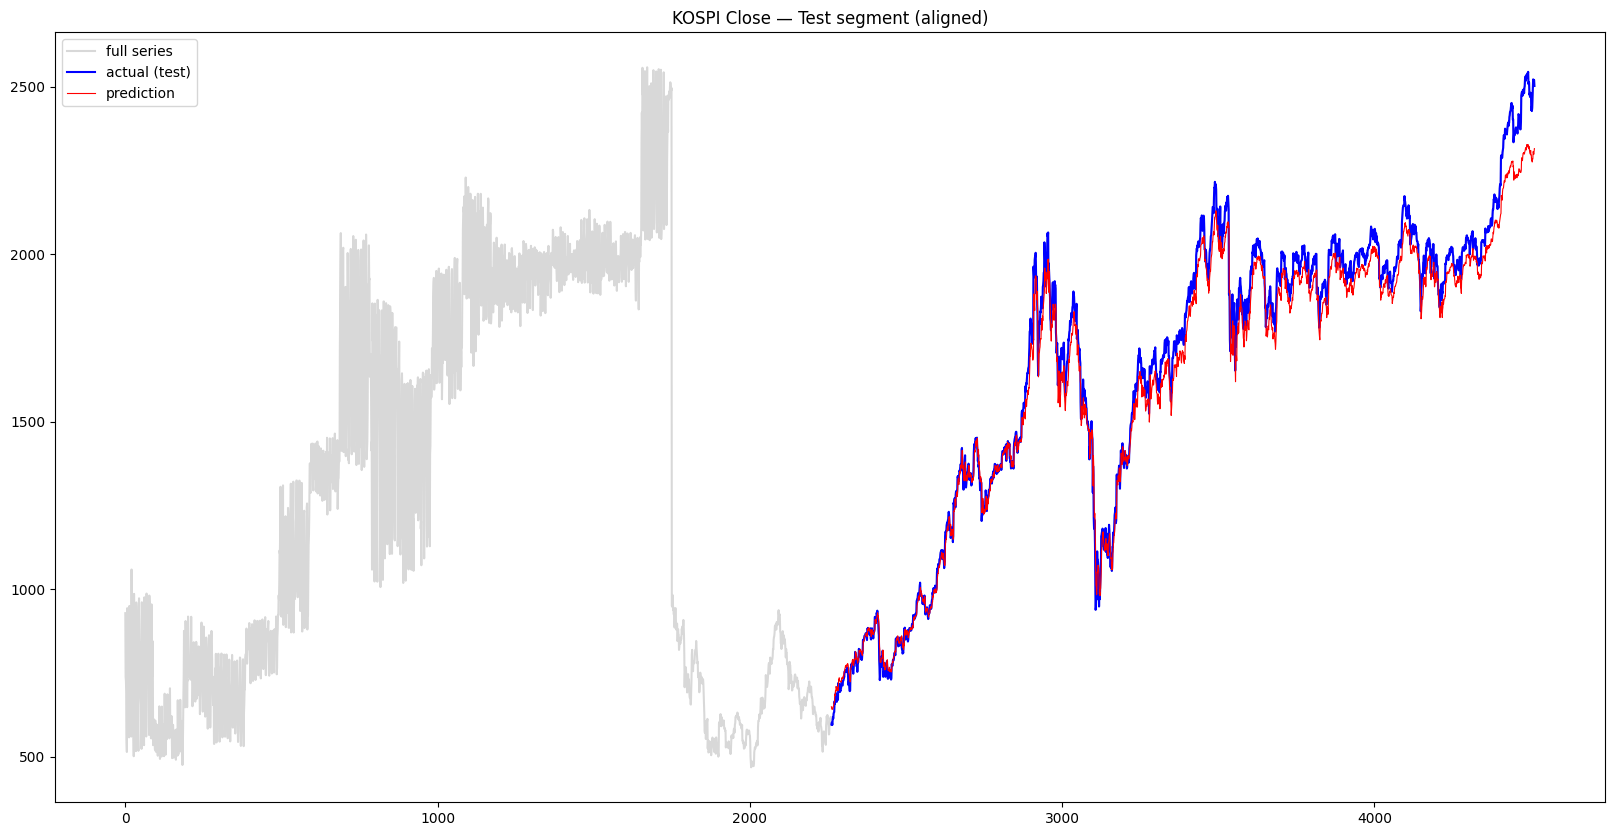

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) 기준 인덱스들
L = sequence_length          # 예: 5
t0 = split_idx               # train/test 절단 시점 (원본 df 기준)
N_pred = len(pred_unscaled)  # 테스트 예측 길이 = len(test_df) - L

# 2) 실제값(테스트 구간)과 예측값 준비
y_actual_test = df['Close'].values[t0 + L : t0 + L + N_pred]   # 테스트 구간 실제 종가
y_pred_test   = pred_unscaled.ravel()                          # 예측(원 스케일)

# 3) x축(원본 인덱스)에 정확히 맞춰 그림
x_test = np.arange(t0 + L, t0 + L + N_pred)

plt.figure(figsize=(20, 10))

plt.plot(df['Close'].values, color='gray', alpha=0.3, label='full series')

# 테스트 실제/예측 정렬해서 겹치기
plt.plot(x_test, y_actual_test, 'b', label='actual (test)')
plt.plot(x_test, y_pred_test, 'r', linewidth=0.8, label='prediction')

plt.legend()
plt.title('KOSPI Close — Test segment (aligned)')
plt.show()